In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score

In [9]:
df = pd.read_csv("../data/processed/ai_job_dataset_cleaned.csv")

df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name,skills_list
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics,"['Tableau', 'PyTorch', 'Kubernetes', 'Linux', ..."
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc,"['Deep Learning', 'AWS', 'Mathematics', 'Pytho..."
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech,"['Kubernetes', 'Deep Learning', 'Java', 'Hadoo..."
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems,"['Scala', 'SQL', 'Linux', 'Python']"
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics,"['MLOps', 'Java', 'Tableau', 'Python']"


In [10]:
df.columns

Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name', 'skills_list'],
      dtype='object')

In [11]:
model_df = df.copy()

In [12]:
# Encode categorical variables for machine learning

categorical_cols = [
    "experience_level",
    "employment_type",
    "company_location",
    "company_size",
    "employee_residence",
    "education_required",
    "industry",
    "job_title"
]

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    label_encoders[col] = le

model_df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name,skills_list
0,AI00001,3,90376,USD,3,0,3,1,3,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",1,9,0,2024-10-18,2024-11-07,1076,5.9,Smart Analytics,"['Tableau', 'PyTorch', 'Kubernetes', 'Linux', ..."
1,AI00002,4,61895,USD,0,0,2,1,9,100,"Deep Learning, AWS, Mathematics, Python, Docker",2,1,9,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc,"['Deep Learning', 'AWS', 'Mathematics', 'Pytho..."
2,AI00003,5,152626,USD,2,1,17,0,15,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",0,2,2,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech,"['Kubernetes', 'Deep Learning', 'Java', 'Hadoo..."
3,AI00004,16,80215,USD,3,1,8,1,8,50,"Scala, SQL, Linux, Python",3,7,1,2024-12-23,2025-02-24,1345,8.6,Future Systems,"['Scala', 'SQL', 'Linux', 'Python']"
4,AI00005,1,54624,EUR,0,3,6,2,14,100,"MLOps, Java, Tableau, Python",2,0,9,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics,"['MLOps', 'Java', 'Tableau', 'Python']"


In [13]:
# Features used to predict salary

features = [
    "experience_level",
    "employment_type",
    "company_location",
    "company_size",
    "employee_residence",
    "remote_ratio",
    "education_required",
    "years_experience",
    "industry",
    "job_description_length",
    "benefits_score",
    "job_title"
]

X = model_df[features]
y = model_df["salary_usd"]

X.head()

,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,industry,job_description_length,benefits_score,job_title
0,3,0,3,1,3,50,1,9,0,1076,5.9,3
1,0,0,2,1,9,100,2,1,9,1268,5.2,4
2,2,1,17,0,15,0,0,2,2,1974,9.4,5
3,3,1,8,1,8,50,3,7,1,1345,8.6,16
4,0,3,6,2,14,100,2,0,9,1989,6.6,1


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 12000
Testing rows: 3000


In [15]:
# Baseline model: Linear Regression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_preds = linear_model.predict(X_test)

linear_mse = mean_squared_error(y_test, linear_preds)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_preds)

print("Linear Regression Results")
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

Linear Regression Results
MSE: 1395098437.4901028
RMSE: 37351.016552298854
R2 Score: 0.6174866084953908


/Users/milipatel/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/milipatel/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/milipatel/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [16]:
# Improved model: Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_preds)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Results")
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
MSE: 458339345.5111256
RMSE: 21408.861378203317
R2 Score: 0.8743307763809983


In [17]:
# Compare model performance

model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MSE": [linear_mse, rf_mse],
    "RMSE": [linear_rmse, rf_rmse],
    "R2 Score": [linear_r2, rf_r2]
})

model_results

,Model,MSE,RMSE,R2 Score
0,Linear Regression,1.395098e+09,37351.016552,0.617487
1,Random Forest,4.583393e+08,21408.861378,0.874331


In [18]:
model_results.to_csv("../outputs/models/model_comparison_results.csv", index=False)

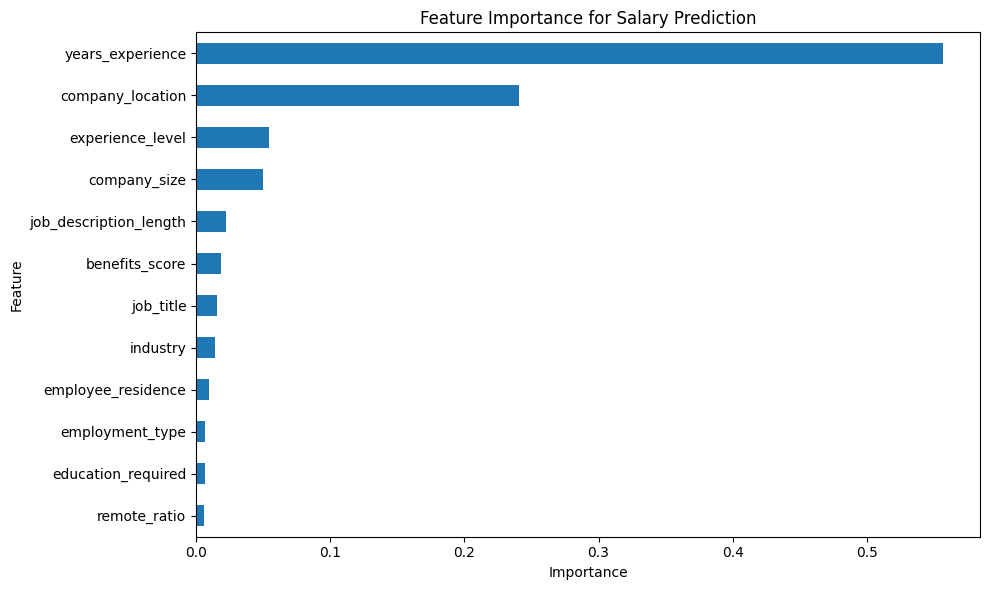

In [19]:
# Feature importance from Random Forest model

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))

feature_importance.plot(kind="barh")

plt.title("Feature Importance for Salary Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig("../outputs/figures/feature_importance.png")
plt.show()

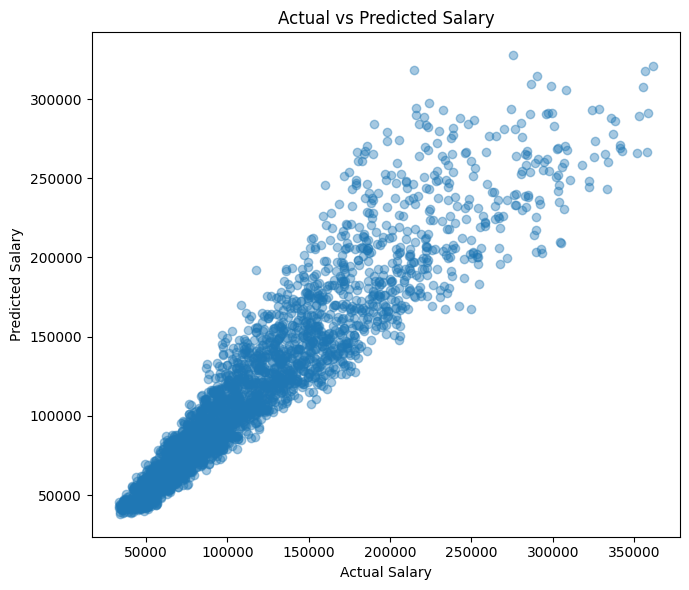

In [20]:
# Actual vs predicted salary plot

plt.figure(figsize=(7, 6))

plt.scatter(y_test, rf_preds, alpha=0.4)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.tight_layout()
plt.savefig("../outputs/figures/actual_vs_predicted_salary.png")
plt.show()

In [21]:
# Clustering jobs based on salary and experience

cluster_features = model_df[[
    "salary_usd",
    "years_experience",
    "remote_ratio",
    "benefits_score"
]]

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

In [22]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

model_df["cluster"] = kmeans.fit_predict(cluster_scaled)

model_df[["salary_usd", "years_experience", "remote_ratio", "benefits_score", "cluster"]].head()

/Users/milipatel/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/milipatel/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/milipatel/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/milipatel/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/milipatel/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/milipatel/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  curr

,salary_usd,years_experience,remote_ratio,benefits_score,cluster
0,90376,9,50,5.9,2
1,61895,1,100,5.2,0
2,152626,2,0,9.4,2
3,80215,7,50,8.6,0
4,54624,0,100,6.6,0


In [23]:
silhouette = silhouette_score(cluster_scaled, model_df["cluster"])

print("Silhouette Score:", silhouette)

/Users/milipatel/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/milipatel/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/milipatel/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/milipatel/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/milipatel/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/milipatel/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Silhouette Score: 0.26068683636931345


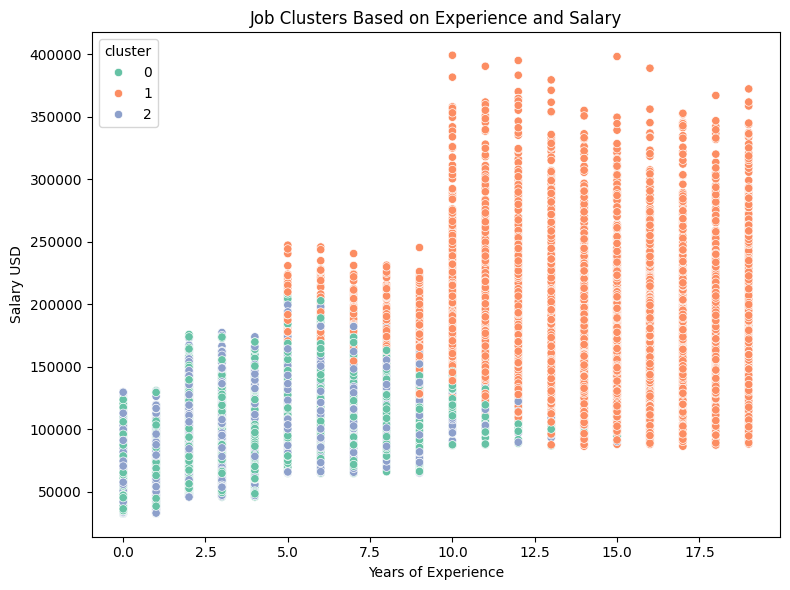

In [24]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=model_df,
    x="years_experience",
    y="salary_usd",
    hue="cluster",
    palette="Set2"
)

plt.title("Job Clusters Based on Experience and Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary USD")

plt.tight_layout()
plt.savefig("../outputs/figures/job_clusters.png")
plt.show()

In [25]:
cluster_summary = model_df.groupby("cluster")[[
    "salary_usd",
    "years_experience",
    "remote_ratio",
    "benefits_score"
]].mean()

cluster_summary

,salary_usd,years_experience,remote_ratio,benefits_score
cluster,,,,
0,88308.341477,3.489370,84.026483,7.955427
1,189595.885021,13.825202,49.779358,7.481858
2,86951.526354,3.363015,15.947113,7.085555


In [26]:
cluster_summary.to_csv("../outputs/models/cluster_summary.csv")

In [27]:
print("Final Project Modeling Summary")
print("--------------------------------")
print("Linear Regression R2:", linear_r2)
print("Random Forest R2:", rf_r2)
print("Clustering Silhouette Score:", silhouette)

Final Project Modeling Summary
--------------------------------
Linear Regression R2: 0.6174866084953908
Random Forest R2: 0.8743307763809983
Clustering Silhouette Score: 0.26068683636931345
